In [57]:
# Interpretations written in the context of varying environments, but can be used for Parkinson's mouse, just make sure to change the interpretation.

# copy of the areanas metrics.ipynb, modified to fit mitopark. modified to use .csv as input.

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
import h5py
import os
import re
from collections import Counter
from scipy.stats import entropy
from scipy.spatial.distance import jensenshannon
from scipy.spatial.distance import cosine

In [60]:
# curr_dir = os.getcwd()
# base_dir = os.path.dirname(curr_dir)
# data_dir = os.path.join(base_dir, 'Data')
# temp = os.path.join( data_dir , 'mitopark')
# filename = os.path.join( temp , 'Cluster_detail_results.csv') 

In [61]:
filename = r'Z:\Members\Mia-Sanjana-Hadent\Processed Data\FOR SANJANA Testing_Mouse1\combined_matrix_final_total1.csv'
clusters_data = pd.read_csv( filename )
clusters_data = clusters_data.dropna()
clusters_data

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,...,Feature_23,Feature_24,Feature_25,Feature_26,Feature_27,Feature_28,Feature_29,Feature_30,ClusterNumber,ExperimentType
0,0.0,0.0,0.0,0.0,0.000000,1.000000,0.0,0.00,0.00,0.0,...,0.000000,0.166667,0.383333,0.450000,0.000000,0.000000,0.000000,1.000000,1.0,OF
1,0.0,0.0,0.0,0.0,0.516667,0.483333,0.0,0.00,0.00,0.0,...,0.100000,0.100000,0.483333,0.300000,0.016667,0.000000,0.033333,0.966667,1.0,OF
2,0.0,0.0,0.0,0.0,0.000000,1.000000,0.0,0.00,0.00,0.0,...,0.300000,0.066667,0.233333,0.083333,0.100000,0.216667,0.000000,1.000000,1.0,OF
3,0.0,0.0,0.0,0.0,0.000000,1.000000,0.0,0.00,0.00,0.0,...,0.133333,0.033333,0.133333,0.283333,0.266667,0.150000,0.000000,1.000000,1.0,OF
4,0.0,0.0,0.0,0.0,0.000000,1.000000,0.0,0.00,0.00,0.0,...,0.000000,0.016667,0.150000,0.266667,0.350000,0.216667,0.033333,0.966667,1.0,OF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32167,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.25,0.75,0.0,...,0.400000,0.216667,0.316667,0.066667,0.000000,0.000000,0.000000,1.000000,2.0,SB
32168,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,1.00,0.00,0.0,...,0.066667,0.150000,0.516667,0.266667,0.000000,0.000000,0.083333,0.916667,9.0,SB
32169,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,1.00,0.00,0.0,...,0.066667,0.133333,0.383333,0.416667,0.000000,0.000000,0.000000,1.000000,40.0,SB
32170,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,1.00,0.00,0.0,...,0.000000,0.000000,0.133333,0.866667,0.000000,0.000000,0.000000,1.000000,3.0,SB


In [62]:
# there should only be 5 folders , so modifying. but for this dataset specifically

# clusters_data.loc[clusters_data["Folder_Name"] == 2, "Folder_Name"] = 1
# clusters_data.loc[clusters_data["Folder_Name"] == 3, "Folder_Name"] = 2
# clusters_data.loc[clusters_data["Folder_Name"] == 4, "Folder_Name"] = 2
# clusters_data.loc[clusters_data["Folder_Name"] == 5, "Folder_Name"] = 4
# clusters_data.loc[clusters_data["Folder_Name"] == 6, "Folder_Name"] = 5
# clusters_data.loc[clusters_data["Folder_Name"] == 7, "Folder_Name"] = 5
# clusters_data.loc[clusters_data["Folder_Name"] == 8, "Folder_Name"] = 5


# clusters_data['week_num'] = clusters_data['Folder_Name'].str.extract(r'week(\d+)').astype(int)
# unique_weeks = sorted(clusters_data['week_num'].unique())
# week_to_stage = {week: i+1 for i, week in enumerate(unique_weeks)}
# clusters_data['arena'] = clusters_data['week_num'].map(week_to_stage)
# clusters_data.drop(columns='week_num', inplace=True)

# clusters_data.drop(columns='Folder_Name', inplace=True)

clusters_data = clusters_data.loc[:, ~clusters_data.columns.str.contains('Feature_', case=False)]
mapping = {'OF': 1, 'BL': 2, 'SB': 3}
clusters_data['ExperimentType'] = clusters_data['ExperimentType'].map(mapping)


clusters_data

C:\Users\gangliaguardian\AppData\Local\Temp\ipykernel_20284\3619366038.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clusters_data['ExperimentType'] = clusters_data['ExperimentType'].map(mapping)


,ClusterNumber,ExperimentType
0,1.0,1
1,1.0,1
2,1.0,1
3,1.0,1
4,1.0,1
...,...,...
32167,2.0,3
32168,9.0,3
32169,40.0,3
32170,3.0,3


In [63]:
# clusters_data = clusters_data.drop(0, axis=1)
clusters_data = clusters_data.rename(columns={ 'ClusterNumber' : 'cluster'})
# clusters_data = clusters_data.rename(columns={ 'Folder_Name': 'arena'})

n_clusters = int(clusters_data['cluster'].max()) + 1

clusters_data

,cluster,ExperimentType
0,1.0,1
1,1.0,1
2,1.0,1
3,1.0,1
4,1.0,1
...,...,...
32167,2.0,3
32168,9.0,3
32169,40.0,3
32170,3.0,3


In [64]:
# also making dfs for arenas, for ease of use

df_OF = clusters_data[clusters_data['ExperimentType'] == 1 ].reset_index(drop=True)
df_BL = clusters_data[clusters_data['ExperimentType'] == 2 ].reset_index(drop=True)
df_SB = clusters_data[clusters_data['ExperimentType'] == 3 ].reset_index(drop=True)

In [65]:
# Context Specificity Index 

# Get cluster sets for each stage
clusters_OF = set(df_OF['cluster'].unique())
clusters_BL = set(df_BL['cluster'].unique())
clusters_SB = set(df_SB['cluster'].unique())

# Compute CSI relative to Stage 1
def compute_csi(stage_clusters, ref_clusters):
    return (len(stage_clusters) - len(ref_clusters)) / (len(stage_clusters) + len(ref_clusters))

csi_BL = compute_csi(clusters_BL, clusters_OF)
csi_SB = compute_csi(clusters_SB, clusters_OF)

print("Context Specificity Index (relative to OF):")
for i, csi in enumerate([csi_BL, csi_SB], start=2):
    print(f"{i}: {csi:.3f}")

# > 0 --> there are more unique clusters that were expressed in stage x when compared to OF. doesn't indicate any overlap in clusters, just the number expressed in each stage


Context Specificity Index (relative to OF):
2: 0.010
3: 0.010


In [66]:
# Novelty index: fraction of clusters unique. 

# Compute cluster sets
clusters_stage1 = set(df_OF['cluster'].unique())
clusters_stage2 = set(df_BL['cluster'].unique())
clusters_stage3 = set(df_SB['cluster'].unique())

# Compute novelty per stage
def novelty_index(stage_clusters):
    return len(stage_clusters - clusters_stage1) / len(clusters_stage1)

novelty_BL = novelty_index(clusters_BL)
novelty_SB = novelty_index(clusters_SB)

print("Novelty Index (relative to OF):")
for i, n in enumerate([novelty_BL, novelty_SB], start=2):
    print(f"{i}: {n:.3f}")

# > 0.3 --> many new clusters were introduced in stage x, again doesn't indicate anything about the overlap of clusters
# 0.1 - 0.3 --> some new clusters introduced in stage x when compared to stage 1
# this doesn't tell you if old clusters were lost! purely based on size

Novelty Index (relative to OF):
2: 0.019
3: 0.019


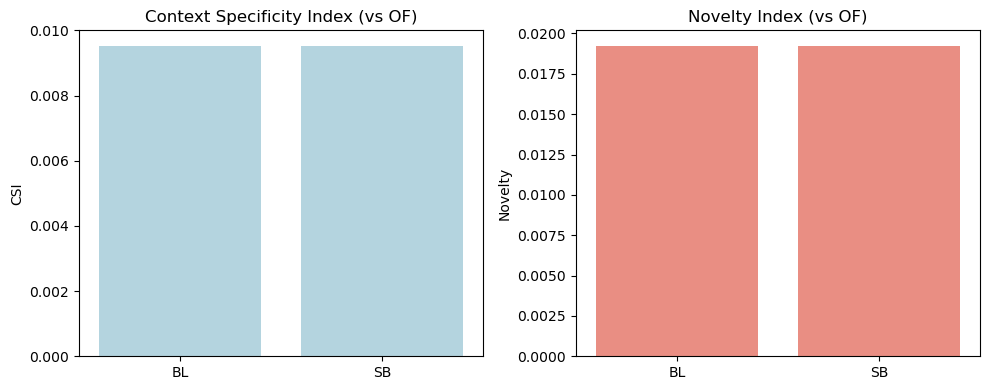

In [67]:
stages = ['BL', 'SB']
csi_values = [csi_BL, csi_SB]
novelty_values = [novelty_BL, novelty_SB ]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.barplot(x=stages, y=csi_values, ax=axes[0], color='lightblue')
axes[0].set_title("Context Specificity Index (vs OF)")
axes[0].set_ylabel("CSI")

sns.barplot(x=stages, y=novelty_values, ax=axes[1], color='salmon')
axes[1].set_title("Novelty Index (vs OF)")
axes[1].set_ylabel("Novelty")

plt.tight_layout()
plt.show()


Max Shannon entropy: 5.727920454563199


C:\Users\gangliaguardian\AppData\Local\Temp\ipykernel_20284\2399139657.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stages, y=rep_sizes, ax=axs[0], palette='Blues_d')
C:\Users\gangliaguardian\AppData\Local\Temp\ipykernel_20284\2399139657.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stages, y=entropies, ax=axs[1], palette='Greens_d')


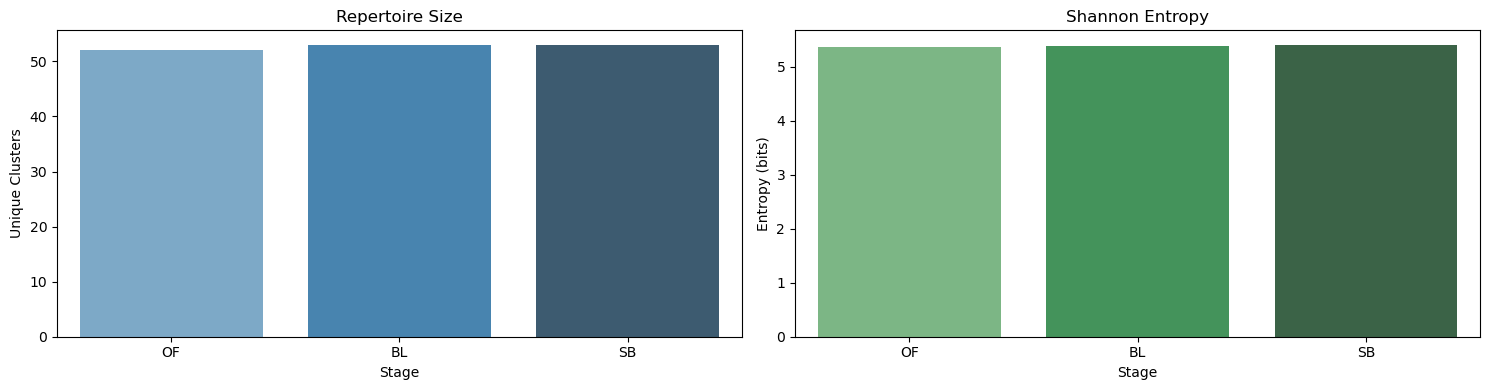

In [68]:
def compute_shannon_entropy(df):
    p = df['cluster'].value_counts(normalize=True)
    return entropy(p, base=2)

# Store all stage DataFrames (OF, BL, SB)
dfs = [df_OF, df_BL, df_SB]
stages = ["OF", "BL", "SB"]

# Compute repertoire sizes and entropies
rep_sizes = [df['cluster'].nunique() for df in dfs]
entropies = [compute_shannon_entropy(df) for df in dfs]

# Total number of unique clusters across all stages
n_clusters = len(pd.concat(dfs)['cluster'].unique())
max_shannon_entropy = np.log2(n_clusters)
print("Max Shannon entropy:", max_shannon_entropy)

# Normalize entropy (% of maximum)
entropy_norm = [e / np.log2(n_clusters) * 100 for e in entropies]

# Plot
fig, axs = plt.subplots(1, 2, figsize=(15, 4))

sns.barplot(x=stages, y=rep_sizes, ax=axs[0], palette='Blues_d')
axs[0].set(title='Repertoire Size', ylabel='Unique Clusters', xlabel='Stage')

sns.barplot(x=stages, y=entropies, ax=axs[1], palette='Greens_d')
axs[1].set(title='Shannon Entropy', ylabel='Entropy (bits)', xlabel='Stage')

plt.tight_layout()
plt.show()

# repertoire size = number of unique behaviors expressed in each stage

# Higher entropy = higher uncertainty. Shannon entropy specifically tells us how even the behaviors are. If entropy is low, then the animal performs one (or a few) behavior(s) majority of the time and is predictable. 

  Stage  Cosine Similarity  Jensen–Shannon Divergence
0    BL             0.9071                     0.3905
1    SB             0.4284                     0.4709


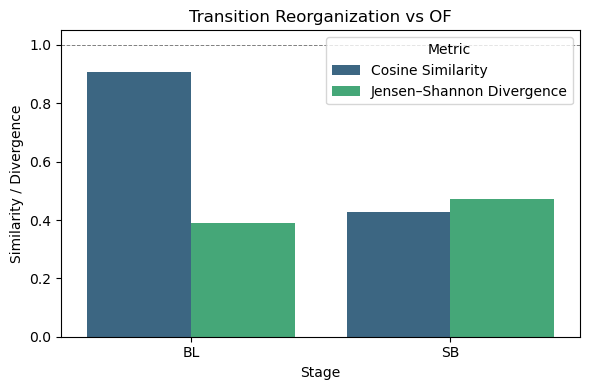

In [75]:
# Measures how the behavioral flow changes across progression

def get_transition_distribution(df, n_clusters):
    clusters = df['cluster'].tolist()
    transitions = list(zip(clusters[:-1], clusters[1:]))
    counts = Counter(transitions)
    vec = np.zeros(n_clusters * n_clusters)
    for (from_c, to_c), c in counts.items():
        idx = int(from_c * n_clusters + to_c)
        if idx < len(vec):
            vec[idx] = c
    return vec / vec.sum() if vec.sum() > 0 else vec

# Compute transition distributions for all stages 
dfs = [df_OF, df_BL, df_SB]
stages = ["OF", "BL", "SB"]

n_clusters = len(pd.concat(dfs)['cluster'].unique())
vecs = [get_transition_distribution(df, n_clusters) for df in dfs]

# Compare each stage to Stage 1 baseline
results = []
for i in range(1, len(vecs)):
    cos_sim = 1 - cosine(vecs[0], vecs[i])
    jsd = jensenshannon(vecs[0], vecs[i], base=2)
    results.append({
        'Stage': stages[i], 
        'Cosine Similarity': cos_sim,
        'Jensen–Shannon Divergence': jsd
    })

df_trans = pd.DataFrame(results)
print(df_trans.round(4))

fig, ax1 = plt.subplots(figsize=(6,4))
sns.barplot(data=df_trans.melt(id_vars='Stage', var_name='Metric', value_name='Value'),
            x='Stage', y='Value', hue='Metric', palette='viridis', ax=ax1)
ax1.set(title='Transition Reorganization vs OF',
        ylabel='Similarity / Divergence',
        xlabel='Stage')
plt.axhline(1, color='gray', ls='--', lw=0.7)
plt.tight_layout()
plt.show()

# cosine : closer to 1, the more the distributions are the same. 
# Jensen-Shannon divergence : closer to 0 = both distributions are identical. We are expecting a higher jsd value, because the more later stages should have different transitions not showcased in the earlier stages

,Stage,Unique n-grams,Shared w/ OF,New (vs OF),Lost (vs OF)
0,OF,3525,3525,0,0
1,BL,4535,1592,2943,1933
2,SB,4662,1612,3050,1913


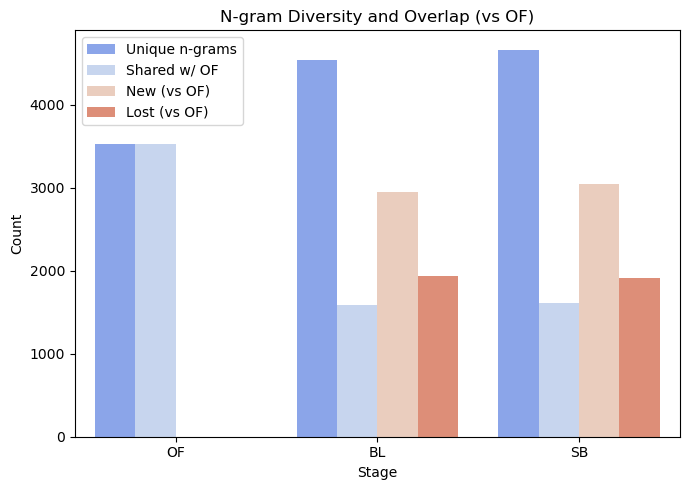

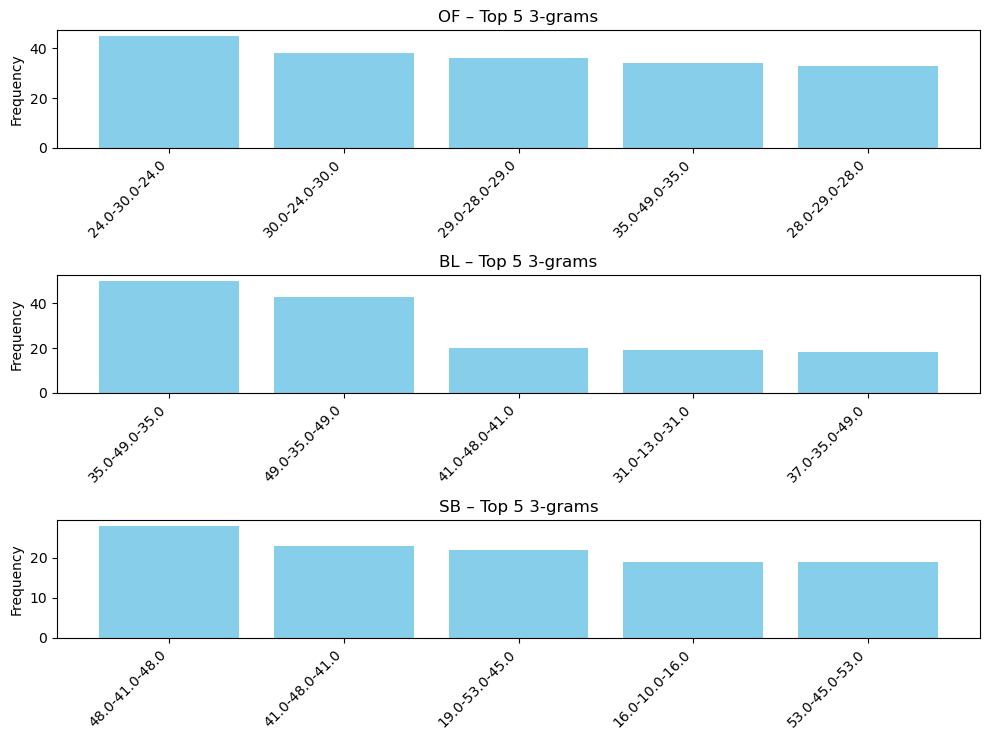

In [70]:
def extract_ngrams_with_counts(df, n=2, exclude_repeats=False, collapse_repeats=False):
    clusters = df['cluster'].tolist()
    if collapse_repeats:
        clusters = [v for i, v in enumerate(clusters) if i == 0 or v != clusters[i-1]]

    ngrams = []
    for i in range(len(clusters) - n + 1):
        ng = tuple(clusters[i:i+n])
        if exclude_repeats and any(ng[j] == ng[j+1] for j in range(n-1)):
            continue
        ngrams.append(ng)
    c = Counter(ngrams)
    return set(c.keys()), c


def analyze_sequence_diversity_by_stages(dfs, stage_labels, n=2, exclude_repeats=False):
    # Extract n-grams and counts for each stage
    ngram_sets, count_dicts = zip(*[
        extract_ngrams_with_counts(df, n, exclude_repeats, collapse_repeats=True)
        for df in dfs
    ])
    base = ngram_sets[0]

    # Compare each stage vs Stage 1 (OF)
    results = []
    for i, (s, label) in enumerate(zip(ngram_sets, stage_labels)):
        shared = len(base & s)
        new_only = len(s - base)
        lost = len(base - s)
        results.append({
            'Stage': label,
            'Unique n-grams': len(s),
            'Shared w/ OF': shared,
            'New (vs OF)': new_only,
            'Lost (vs OF)': lost
        })
    return pd.DataFrame(results), count_dicts


# Updated stage DataFrames and labels
dfs = [df_OF, df_BL, df_SB]
stage_labels = ['OF', 'BL', 'SB']

ngram_results, count_dicts = analyze_sequence_diversity_by_stages(dfs, stage_labels, n=3, exclude_repeats=True)
display(ngram_results)

plt.figure(figsize=(7,5))
sns.barplot(
    data=ngram_results.melt(
        id_vars='Stage',
        value_vars=['Unique n-grams', 'Shared w/ OF', 'New (vs OF)', 'Lost (vs OF)']
    ),
    x='Stage', y='value', hue='variable', palette='coolwarm'
)
plt.title('N-gram Diversity and Overlap (vs OF)')
plt.ylabel('Count')
plt.xlabel('Stage')
plt.legend(title='')
plt.tight_layout()
plt.show()


def plot_top_ngrams_stagewise(count_dicts, stage_labels, top_n=5, n=3):
    fig, axes = plt.subplots(len(count_dicts), 1, figsize=(10, 2.5 * len(count_dicts)))
    if len(count_dicts) == 1:
        axes = [axes]

    for i, (counts, ax) in enumerate(zip(count_dicts, axes)):
        top = counts.most_common(top_n)
        if not top:
            continue
        labels, vals = zip(*top)
        labels = ['-'.join(map(str, l)) for l in labels]
        ax.bar(range(len(labels)), vals, color='skyblue')
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=45, ha='right')
        ax.set_title(f'{stage_labels[i]} – Top {top_n} {n}-grams')
        ax.set_ylabel('Frequency')
    plt.tight_layout()
    plt.show()

plot_top_ngrams_stagewise(count_dicts, stage_labels, top_n=5, n=3)


In [71]:
# Transition entropy = Shannon entropy but for transition probabilities. Calculated as Htrans = -∑ij [p(i -> j )]log[p(i -> j )]
def compute_transition_entropy( df ):
    df['next_cluster'] = df['cluster'].shift(-1)
    df = df.dropna(subset=['next_cluster'])
    transition_counts = df.groupby(['cluster', 'next_cluster']).size().unstack(fill_value=0)
    transition_probs = transition_counts.div(transition_counts.sum(axis=1), axis=0)
    transition_entropy_per_cluster = transition_probs.apply(lambda row: entropy(row, base=2), axis=1)
    return transition_entropy_per_cluster.mean()

# Since it's transitions, we have to use specifically for each environment since the data between the two dfs shouldn't count as a transition
transition_entropy_OF = compute_transition_entropy( df_OF )
transition_entropy_BL = compute_transition_entropy( df_BL )
transition_entropy_SB = compute_transition_entropy( df_SB )

# This calculates the average across all clusters, regardless of how often each cluster is used. All clusters treated equally, even if rarely used. "Potential transition capacity"

In [72]:
# Calculate Markov entropy, which tells us how predictable the next behavior is, given the current one. Low Markov entropy means that certain transitions occur repeatedly, and the pattern of behavior is more predictable. Entropy should increase as the arenas get more complex. 
# More accurate representation than Shannon entropy for transitions because it accounts for how often each state is visited. "Actual behavioral predictability"

def compute_markov_entropy( df ):
    clusters = df['cluster'].tolist()
    
    transitions = list(zip(clusters[:-1], clusters[1:]))
    transition_counts = Counter(transitions)
    
    outgoing_counts = {}
    for (from_c, to_c), count in transition_counts.items():
        outgoing_counts.setdefault(from_c, 0)
        outgoing_counts[from_c] += count
    
    total_entropy = 0
    total_transitions = sum(transition_counts.values())

    for (from_c, to_c), count in transition_counts.items():
        p_conditional = count / outgoing_counts[from_c]  
        weighted_entropy = (count / total_transitions) * (-np.log2(p_conditional))
        total_entropy += weighted_entropy

    return total_entropy

markov_entropy_OF = compute_markov_entropy( df_OF )
markov_entropy_BL = compute_markov_entropy( df_BL )
markov_entropy_SB = compute_markov_entropy( df_SB )


In [73]:
# Gap between Markov and Shannon transition entropy. Capacity vs usage gap. 

entropy_gap_OF = markov_entropy_OF - transition_entropy_OF
entropy_gap_BL = markov_entropy_BL - transition_entropy_BL
entropy_gap_SB = markov_entropy_SB - transition_entropy_SB

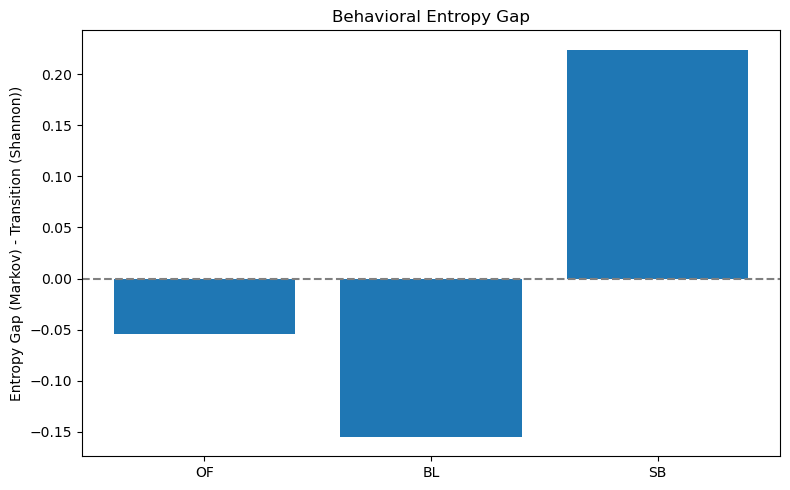

In [74]:
entropy_gaps = [
    entropy_gap_OF,
    entropy_gap_BL,
    entropy_gap_SB
]

stages = ['OF', 'BL', 'SB']

plt.figure(figsize=(8, 5))
bars = plt.bar(stages, entropy_gaps )
plt.axhline(0, color='gray', linestyle='--')
plt.ylabel('Entropy Gap (Markov) - Transition (Shannon))')
plt.title('Behavioral Entropy Gap')
plt.tight_layout()
plt.show()

# positive gap = markov >> transition.  animal's transitions are more inconsistent than the structural map suggets
# negative gap = markov << transition. animal could perform many transitions, but in reality, only utilizes a few of them.